<a href="https://colab.research.google.com/github/PabloDuranL/Miprogresionypraticas/blob/main/KernelRegresion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [467]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [468]:
np.random.seed(123)

In [469]:
N=40
x=np.sort(np.random.rand(N))
e=np.random.normal(0,0.02,N)
y=np.sin(2*np.pi*x)+e


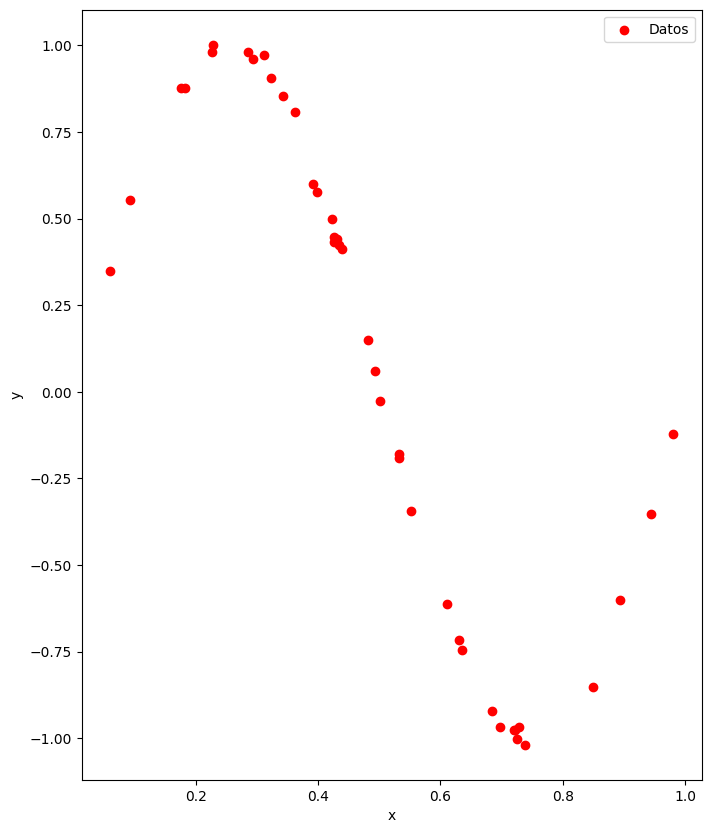

In [470]:

plt.figure(figsize=(8,10))
plt.scatter(x,y,color="red",label="Datos")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [471]:
def RBF(x,centro, sigma):
  return np.exp(-(x-centro)**2/(2*sigma**2))


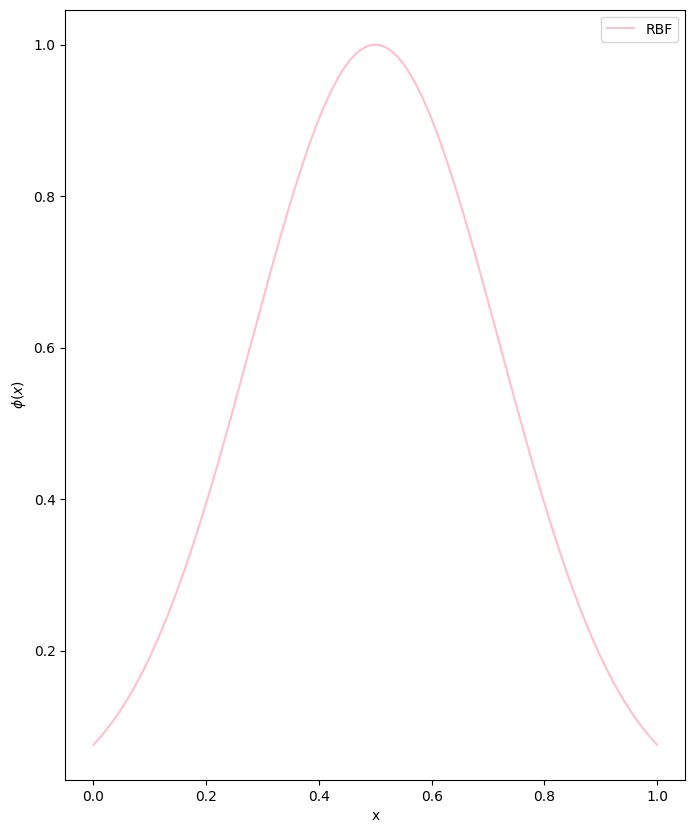

In [472]:
X=np.linspace(0,1,300)
phi= RBF(X,0.5,0.22)
plt.figure(figsize=(8,10))
plt.plot(X,phi,color='pink',label='RBF')
plt.xlabel('x')
plt.ylabel(r"$\phi(x)$")
plt.legend()
plt.show()

In [473]:
M=50
centros=np.random.rand(M)
sigma=0.1

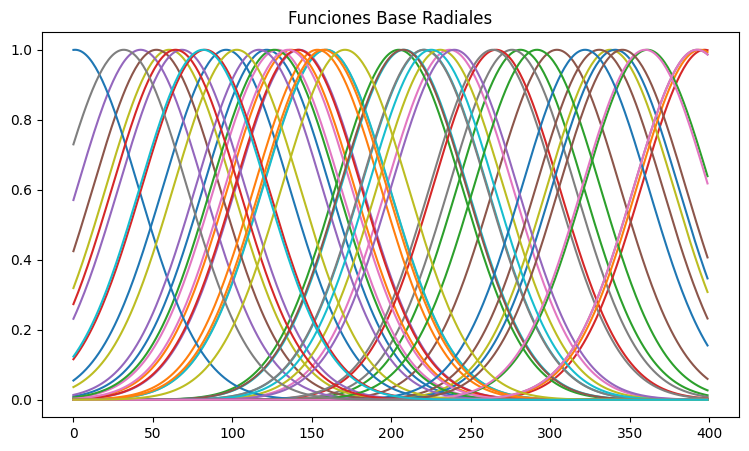

In [474]:
X=np.linspace(0,1,400)

plt.figure(figsize=(9,5))

for c in centros:
    plt.plot(RBF(X,c,sigma))

plt.title("Funciones Base Radiales")

plt.show()

In [475]:
def matriz_design(x,centros,sigma):
  phi=np.zeros((int(len(x)),int(len(centros))))
  for i,c in enumerate(centros):
    phi[:,i]=RBF(x,c,sigma)
  return phi

In [476]:
phi=matriz_design(x,centros,sigma)
phi.shape

(40, 50)

In [477]:
w=np.linalg.inv(phi.T@phi)@phi.T@y

In [478]:
x_grid=np.linspace(0,1,300)
phi_test=matriz_design(x_grid,centros,sigma)
y_pred=phi_test@w


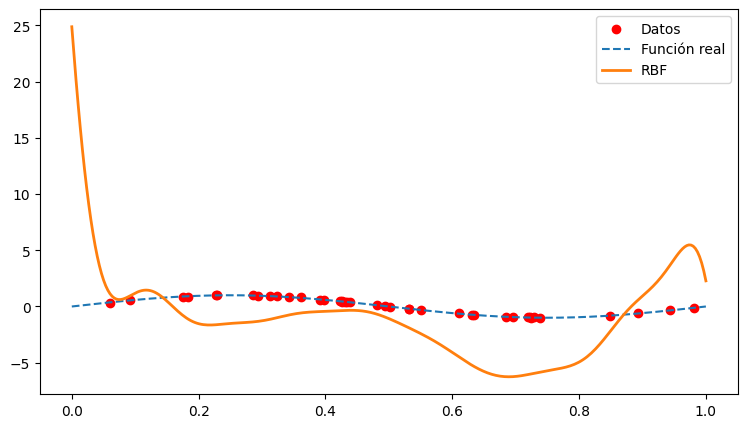

In [479]:
plt.figure(figsize=(9,5))

plt.scatter(x,y,color="red",label="Datos")

plt.plot(x_grid,
         np.sin(2*np.pi*x_grid),
         '--',
         label="Función real")

plt.plot(x_grid,
         y_pred,
         linewidth=2,
         label="RBF")

plt.legend()

plt.show()

In [480]:
alpha = 1

beta = 250

In [481]:
M = phi.shape[1]

I = np.eye(M)

SN = np.linalg.inv(alpha*I + beta*phi.T@phi)

mN = beta*SN@phi.T@y

In [482]:
med=phi_test@mN

In [483]:
var = np.zeros(len(x_grid))

for i in range(len(x_grid)):

    Phi = phi_test[i,:]

    var[i] = 1/beta + Phi.T@SN@Phi

In [484]:
std=np.sqrt(var)

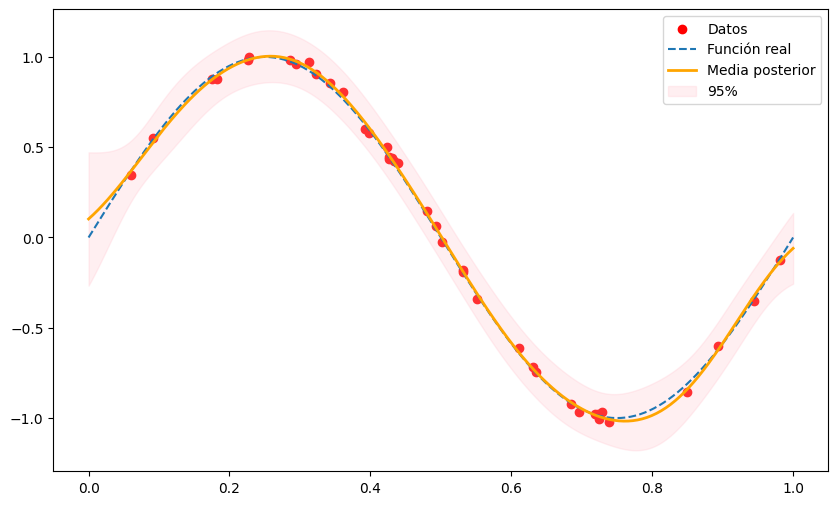

In [485]:
plt.figure(figsize=(10,6))

plt.scatter(x,y,color="red",label="Datos")

plt.plot(
    x_grid,
    np.sin(2*np.pi*x_grid),
    "--",
    label="Función real"
)

plt.plot(
    x_grid,
    med,
    color="orange",
    linewidth=2,
    label="Media posterior"
)

plt.fill_between(
    x_grid,
    med-2*std,
    med+2*std,
    color="pink",
    alpha=0.25,
    label="95%"
)

plt.legend()

plt.show()

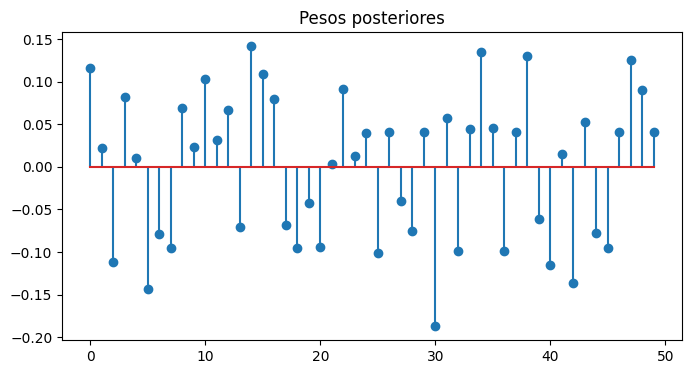

In [486]:
plt.figure(figsize=(8,4))

plt.stem(mN)

plt.title("Pesos posteriores")

plt.show()

In [487]:
samples = np.random.multivariate_normal(
    mN,
    SN,
    5
)

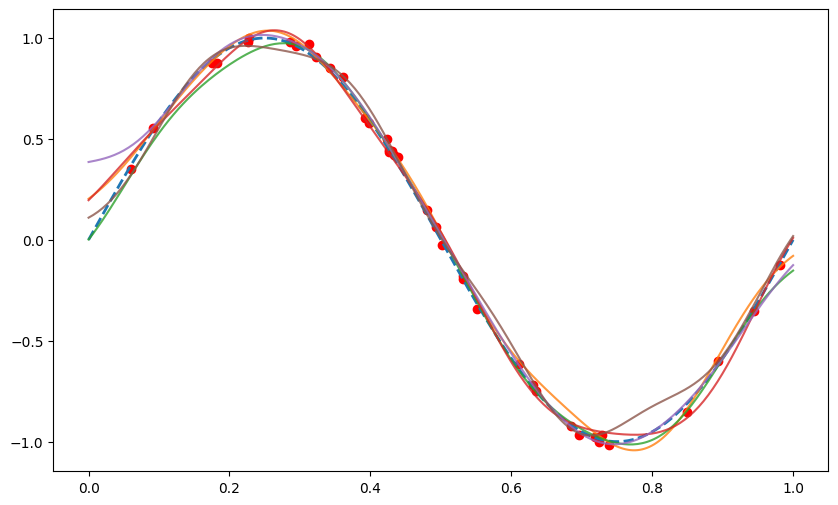

In [488]:
plt.figure(figsize=(10,6))

plt.scatter(x,y,color="red")

plt.plot(x_grid,
         np.sin(2*np.pi*x_grid),
         "--",
         linewidth=2)

for w in samples:

    plt.plot(
        x_grid,
        phi_test@w,
        alpha=0.8
    )

plt.show()

In [489]:
samples = np.random.multivariate_normal(mN, SN, 100)

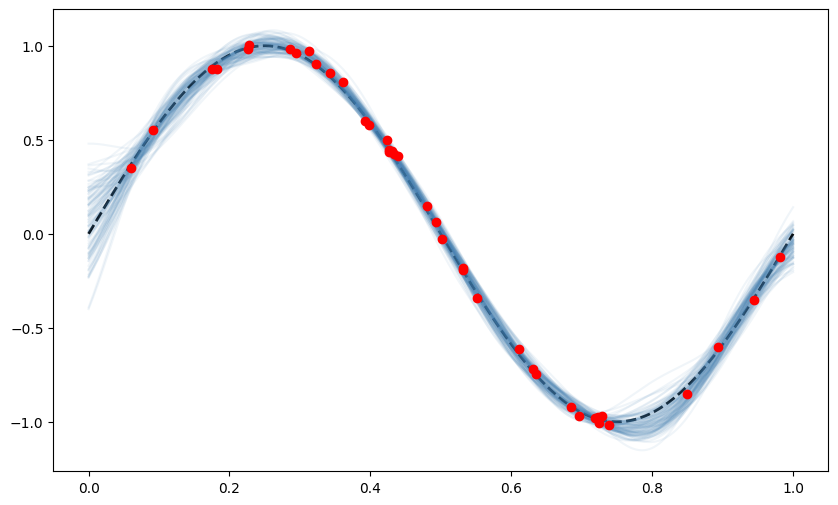

In [490]:
plt.figure(figsize=(10,6))

plt.scatter(x, y, color="red", zorder=3)

plt.plot(x_grid, np.sin(2*np.pi*x_grid), "k--", lw=2)

for w in samples:
    plt.plot(x_grid, phi_test @ w, color="steelblue", alpha=0.08)

plt.show()